In [1]:
import dpluspy
import pickle
import numpy as np

In [2]:
in_fnames = [f"raw_sums/Behrer_sums_{i}.pkl" for i in range(1, 23)]

sums = {}
for fname in in_fnames:
    with open(fname, "rb") as fin:
        sums.update(pickle.load(fin))

bins = sums[next(iter(sums))]["bins"]
pop_ids = sums[next(iter(sums))]["pop_ids"]

replicates = dpluspy.bootstrapping.get_bootstrap_reps(sums, weighted=True)
varcovs = dpluspy.bootstrapping.compute_varcovs(replicates)
means = dpluspy.bootstrapping.weighted_means_across_regions(sums)

data = {
    "means": means, 
    "varcovs": varcovs, 
    "bins": bins, 
    "pop_ids": pop_ids,
    "replicates": replicates
}
with open("full_stats.pkl", "wb") as fout:
    pickle.dump(data, fout)

# Subset statistics 
sub_bins, sub_means, sub_varcovs = dpluspy.bootstrapping.subset_stats(
    data, min_r=1e-6, max_r=1e-2, return_dict=False)

sub_reps = []
for rep_means in replicates:
    rep = {
        "bins": bins, 
        "pop_ids": pop_ids, 
        "means": rep_means, 
        "varcovs": varcovs
    }
    _, sub_rep_means, __ = dpluspy.bootstrapping.subset_stats(
        rep, min_r=1e-6, max_r=1e-2, return_dict=False)
    sub_reps.append(sub_rep_means)

sub_data = {
    "means": sub_means, 
    "varcovs": sub_varcovs, 
    "bins": sub_bins, 
    "pop_ids": pop_ids
}
with open("subset_stats.pkl", "wb") as fout:
    pickle.dump(sub_data, fout)

sub_data["replicates"] = sub_reps
with open("bootstrap_subset_stats.pkl", "wb") as fout:
    pickle.dump(sub_data, fout)


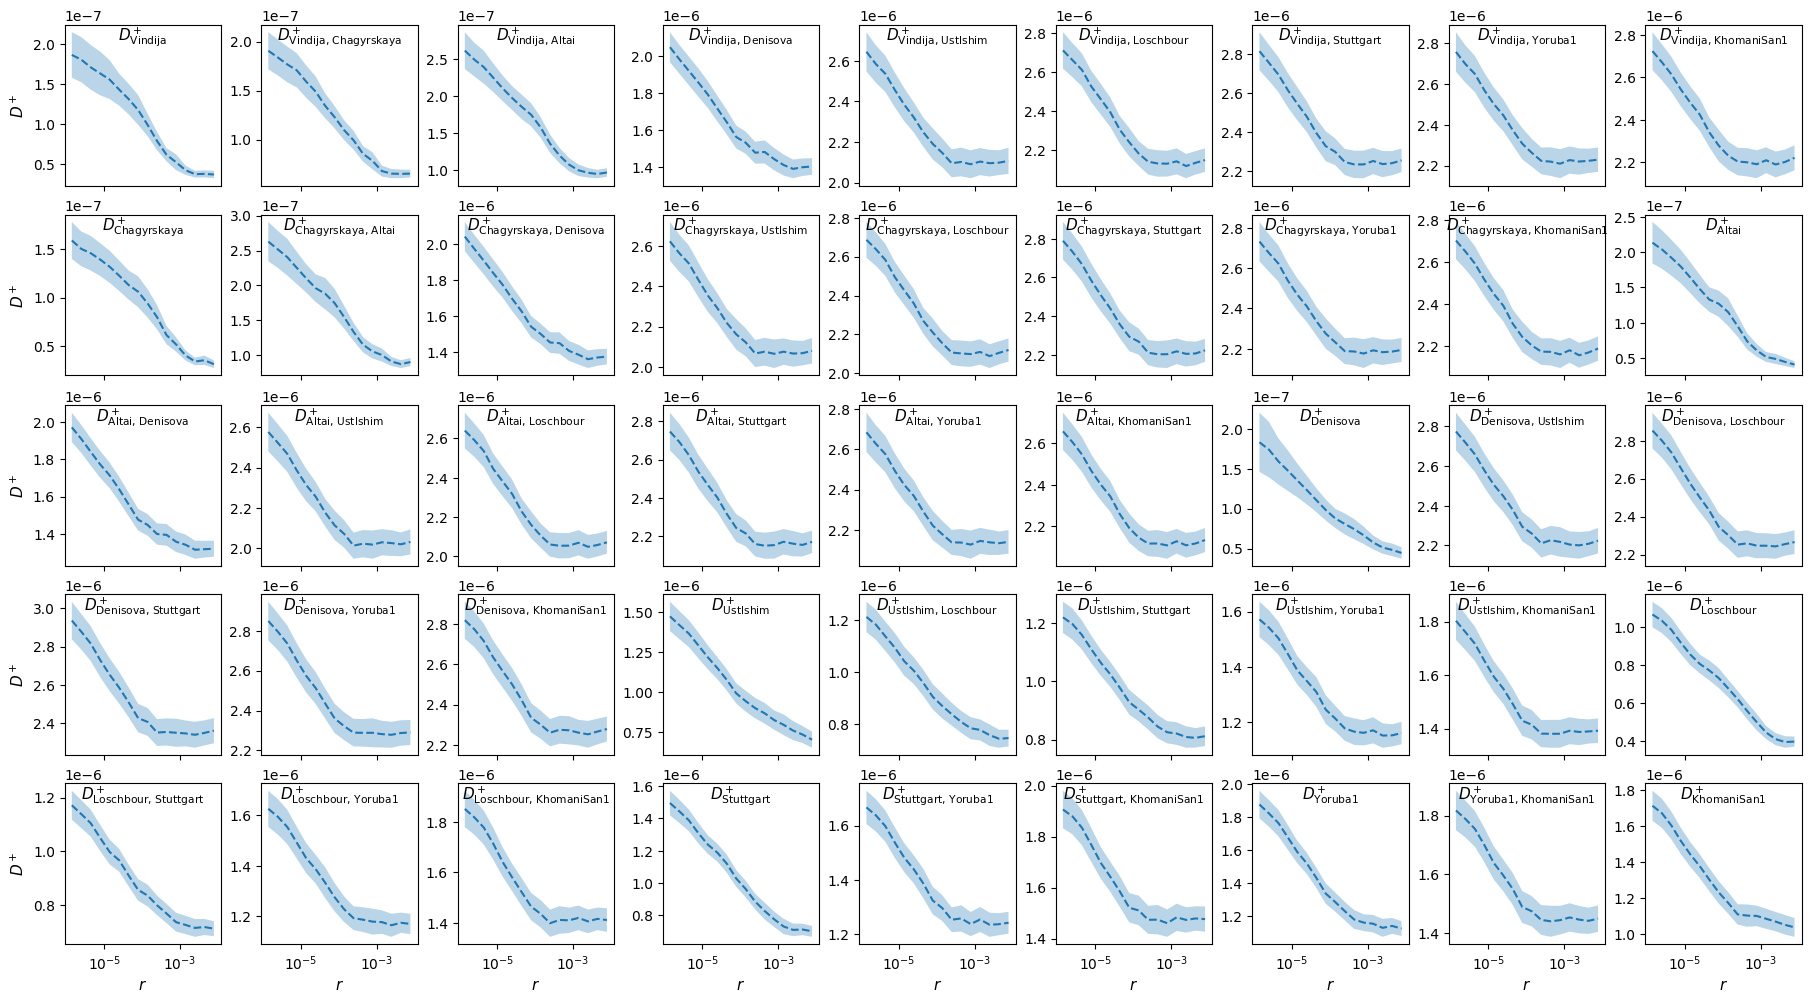

In [3]:
plot_pops = [
    "Vindija",
    "Chagyrskaya",
    "Altai",
    "Denisova",
    "UstIshim",
    "Loschbour",
    "Stuttgart",
    "Yoruba1",
    "KhomaniSan1"
]
pop_ids, bins, means, varcovs = dpluspy.inference.load_stats(
    "subset_stats.pkl", to_pops=plot_pops)
dpluspy.plotting.plot_d_plus_curves(means=means, varcovs=varcovs, bins=bins,
    pop_ids=plot_pops, cols=9, out="fig_summary.pdf")